In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision', 'gymnasium']
imports = {'pillow': 'PIL'}
pinned = {'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "5d733eab198ad58f23ceee3f1550014385366ece"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/5d733eab198ad58f23ceee3f1550014385366ece/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Trust Regions and Proximal Policy Optimization

The methods of the last four sections share a trait that no earlier algorithm in this chapter had: they parameterize the policy directly. Value Iteration and Q-Learning adjusted value estimates and read the policy off them; REINFORCE and actor-critic adjust $\theta$, and the robot's behavior *is* $\pi_\theta$. That raises a question gradient ascent cannot answer on its own, because gradient ascent controls the size of the step in parameters, while what we care about is the size of the step in the policy. This section opens with an example in which the two come apart completely. The answer to that question, together with a way to reuse each batch of trajectories instead of discarding it after one update, gives the two ideas of this section: trust regions [@Schulman.Levine.Abbeel.ea.2015] and the clipped objective of Proximal Policy Optimization [@Schulman.Wolski.Dhariwal.ea.2017], PPO for short. PPO is the workhorse of modern policy optimization; when we discuss how language models are trained from human feedback later in the book, this is the algorithm running underneath.

## Parameter Space versus Policy Space

Since we now update the parameters of the policy directly, we should ask what a parameter update does to the policy itself. A family of policies with a single parameter $\theta$ and two actions answers it; we borrow the example from Joshua Achiam's lectures on policy optimization [@Achiam.2017]. Let

$$\pi_\theta(a) = \begin{cases} \sigma(\theta) & a = 1 \\ 1 - \sigma(\theta) & a = 2, \end{cases} \qquad \textrm{where } \sigma(\theta) = \frac{1}{1 + e^{-\theta}}.$$

Take two parameter updates of exactly the same size, $\Delta\theta = 2$, from two different starting points:

$$\pi_{\theta=0}(a{=}1) = \sigma(0) = 0.50 \ \xrightarrow{\ \Delta\theta = 2\ }\ \sigma(2) = 0.88, \qquad \pi_{\theta=6}(a{=}1) = \sigma(6) = 0.9975 \ \xrightarrow{\ \Delta\theta = 2\ }\ \sigma(8) = 0.9997.$$

The first update takes the robot from indifferent between the two actions to strongly committed to one of them, a drastic change in behavior. The second changes nothing that an observer of the robot could detect. the figure plots the two action distributions before and after each update.

![Two parameter updates of the same size, one from $\theta = 0$ and one from $\theta = 6$, shown as the action distributions before and after each update. The left update rewrites the policy; the right update does not visibly change it.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/rl-policy-vs-parameter.svg)

Both updates move $\theta$ by exactly two. On the left, the distribution flips from even odds to strong commitment. On the right, the before and after bars are indistinguishable. Equal steps in parameter space, wildly unequal steps in policy space: the map from parameters to policies stretches distances in some regions and crushes them in others, so a small change in the parameters can unexpectedly produce a large change in the policy, and a large change can produce none.

The derivative $\sigma'(\theta) = \sigma(\theta)(1 - \sigma(\theta))$ puts numbers on this. At $\theta = 0$ it equals $0.25$; at $\theta = 6$ it is about $0.0025$, a hundred times smaller. No learning rate is right in both regions at once. Worse, the two regions feed each other: near indifference the policy is at its most sensitive, so one noisy oversized update can throw it deep into a saturated region. Once saturated, the score $\nabla_\theta \log \pi_\theta$ is nearly zero, gradients all but vanish, and no sequence of ordinary updates brings the policy back. An on-policy method then keeps collecting data with the broken policy, so the data cannot rescue it either. The run is over, and the learning rate alone could not have prevented it, because capping the step in $\theta$ caps the wrong quantity.

So the quantity to control is the change in the policy, not the change in the parameters: what we want is an update rule that never changes the *policy* by more than we meant to, whatever that costs in parameter distance. Inside that guarantee we also want the freedom to take the largest step it allows and to reuse each batch several times.

## Reusing Data: From On-Policy to Off-Policy

Now to the second want. Every estimator since that section required trajectories sampled from the current policy: one gradient step, and the batch that produced it is stale. On FrozenLake this discipline cost 4096 episodes where Q-Learning needed 256. Suppose instead the batch was collected by an older snapshot of the policy, $\pi_{\theta_{\textrm{old}}}$, and we want to keep learning from it after $\theta$ has moved. What, exactly, can old data tell us about a new policy?

Importance sampling gives the exact answer. For any function $f$ of trajectories,

$$E_{\tau \sim P(\cdot;\, \theta)} \big[ f(\tau) \big] = \sum_\tau P(\tau; \theta)\, f(\tau) = \sum_\tau P(\tau; \theta_{\textrm{old}})\ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, f(\tau) = E_{\tau \sim P(\cdot;\, \theta_{\textrm{old}})} \Big[ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, f(\tau) \Big],$$

valid whenever every trajectory the new policy can produce has positive probability under the old one, a condition softmax policies satisfy automatically because they never assign zero probability to any action. Applied with $f = R$, the return, this rewrites the objective of that section as an expectation under the *old* policy,

$$J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \big[ R(\tau) \big] = E_{\tau \sim P(\cdot;\, \theta_{\textrm{old}})} \Big[ \frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})}\, R(\tau) \Big],$$

so the performance of the new policy can be evaluated, without bias, on data the old policy collected. And the weight is computable: writing out $P(\tau; \theta)$ from the equation, the transition probabilities appear in both numerator and denominator and cancel, the same escape from the unknown MDP as in that section. What remains is a pure product of policy ratios,

$$\frac{P(\tau; \theta)}{P(\tau; \theta_{\textrm{old}})} = \prod_{t=0}^{T-1} \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\textrm{old}}}(a_t \mid s_t)}.$$

Unbiased, however, does not mean usable. Each factor in the product is bounded below by zero and unbounded above, and the product compounds across the trajectory: a trajectory that was unlikely under the old policy but likely under the new one can carry a weight of many orders of magnitude and single-handedly dominate the estimate. The exact correction the equation trades all of its bias for variance that grows with the horizon.

The practical compromise keeps one ratio per step. Define

$$\rho_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\textrm{old}}}(a_t \mid s_t)}$$

and optimize the surrogate objective

$$L(\theta) = \frac{1}{n} \sum_{i=1}^n \sum_{t} \rho_t^i(\theta)\ \hat{A}_t^i,$$

where $\hat{A}_t^i$ is any advantage estimate for step $t$ of trajectory $i$, e.g., the normalized reward-to-go of that section. Two corners have been cut relative to the equation, and both deserve naming: the product of ratios became a single ratio per step, and the states in the batch remain distributed as $\pi_{\theta_{\textrm{old}}}$ visits them, not as $\pi_\theta$ would. In exchange, the weights stay bounded per step and the variance stays manageable. What survives the surgery is local fidelity: at $\theta = \theta_{\textrm{old}}$ every ratio equals one, and differentiating the equation there gives back exactly the policy gradient estimator, since $\nabla_\theta \rho_t \,|_{\theta_{\textrm{old}}} = \nabla_\theta \log \pi_\theta(a_t \mid s_t)\,|_{\theta_{\textrm{old}}}$. The surrogate is a local model of the objective: trustworthy near where it was built and a liar far away. This brings back the first section's concern as a concrete question: how far may $\theta$ move before we must stop trusting $L$?

## Trust Regions

Trust Region Policy Optimization answers with a constraint measured where the two-action example said it must be: in policy space. Maximize the surrogate, but keep the new policy close to the old one,

$$\max_\theta\ L(\theta) \quad \textrm{subject to} \quad \frac{1}{n}\sum_{i,t} \textrm{KL}\big( \pi_{\theta_{\textrm{old}}}(\cdot \mid s_t^i)\ \big\|\ \pi_\theta(\cdot \mid s_t^i) \big) \leq \delta,$$

where the Kullback-Leibler divergence measures, at each visited state, how far the new action distribution has moved from the old one. @Schulman.Levine.Abbeel.ea.2015 show that a version of this scheme improves the true objective monotonically: as long as the policy stays inside the region where the surrogate is trustworthy, ascending the surrogate ascends $J$. Solving the constrained problem takes second-order machinery that we will not build here. The idea to keep is the shape of the guarantee, a step-size rule expressed in policy space rather than parameter space: it does not matter how far $\theta$ moved, it matters how much $\pi_\theta$ moved.

## The Clipped Objective

PPO gets most of the benefit with none of the second-order machinery. Instead of constraining the ratios, clip their usefulness:

$$L^{\textrm{CLIP}}(\theta) = \frac{1}{n} \sum_{i,t} \min\Big( \rho_t^i(\theta)\, \hat{A}_t^i,\ \ \textrm{clip}\big(\rho_t^i(\theta),\ 1-\epsilon,\ 1+\epsilon\big)\, \hat{A}_t^i \Big),$$

with a clipping parameter $\epsilon$, typically $0.2$. Read it one sample at a time. If $\hat{A}_t > 0$, the objective grows with $\rho_t$ but only up to $\rho_t = 1+\epsilon$; past that point the clipped term is smaller and the min selects it, so the sample's gradient becomes zero. The optimizer gains nothing by pushing the action's probability more than $\epsilon$ beyond what the old policy assigned. If $\hat{A}_t < 0$, the same happens on the way down at $1-\epsilon$. The min makes the bound one-sided in the pessimistic direction: a sample can always pull the objective down if the update has made things worse, it just cannot keep paying out for moving further away. Each sample stops contributing once its ratio leaves the band, and an update driven by the equation stalls, per sample, at the edge of the trust region. The stall is an incentive rather than a hard constraint: nothing pins a ratio at the boundary, and gradient steps driven by other samples move the same network and can carry a ratio past the band, which is why the clipped fraction we measure below is not zero. The clip removes the payoff for drifting further, and that is enough in practice. We can now afford several epochs of updates on each batch.

One practical companion deserves a sentence. Implementations usually add a small entropy bonus to the objective, rewarding action distributions that are not too sharp. The two-action example showed what saturation costs: probabilities pinned near one and scores near zero, with no way back. The entropy term is the standing pressure against drifting there.

### Which Advantage Estimate

Anything from the last three sections can serve as $\hat{A}_t$ in the equation. The reward-to-go minus a learned value baseline is the Monte Carlo end of the spectrum; the TD error $\delta_t$ of that section is the bootstrapped end. Generalized Advantage Estimation [@Schulman.Moritz.Levine.ea.2016] interpolates between them with one knob,

$$\hat{A}_t^{\textrm{GAE}(\gamma, \lambda)} = \sum_{l=0}^{\infty} (\gamma \lambda)^l\, \delta_{t+l},$$

where each $\delta$ is the TD error of that section computed from a learned $\hat{V}$ (not the trust-region radius $\delta$ of the previous subsection). At $\lambda = 0$ this is exactly $\delta_t$, maximum bias and minimum variance; at $\lambda = 1$ the sum telescopes to the reward-to-go minus $\hat{V}(s_t)$, the Monte Carlo advantage of that section. Values like $\lambda = 0.95$ are common. Our implementation below uses the $\lambda = 1$ end, the normalized Monte Carlo advantage with the learned baseline of that section; the exercise asks you to swap in the equation.

## Implementation of PPO

We stay on CartPole and reuse the networks and batch helpers of that section:

In [1]:

%matplotlib inline
import numpy as np
import torch
from torch import nn
import gymnasium as gym
from d2l import torch as d2l

gamma = 0.99  # Discount factor
num_updates = 60  # Batches per training run
batch_size = 8  # Episodes per batch
num_seeds = 8  # Independent runs per variant

def make_nets():
    policy = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 2))
    value = nn.Sequential(nn.Linear(4, 64), nn.ReLU(), nn.Linear(64, 1))
    return policy, value

def sample_episode(env, policy):
    state, _ = env.reset()
    states, actions, rewards, done = [], [], [], False
    while not done:
        states.append(state)
        probs = torch.softmax(policy(torch.tensor(state)), dim=-1)
        action = torch.multinomial(probs, 1).item()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        actions.append(action)
        rewards.append(reward)
    return states, actions, rewards

def reward_to_go(rewards):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    return out[::-1]

def collect(env, policy):
    S, A, G, returns = [], [], [], []
    for _ in range(batch_size):
        states, actions, rewards = sample_episode(env, policy)
        returns.append(sum(rewards))
        S += states
        A += actions
        G += reward_to_go(rewards)
    return (torch.tensor(np.array(S)), torch.tensor(A),
            torch.tensor(G), np.mean(returns))

The training loop differs from that section in one place: after collecting a batch and computing advantages, we record the log-probabilities under the collecting policy and then take `num_epochs` passes of updates over the same batch, each maximizing the clipped surrogate the equation against those frozen log-probabilities. The `use_clip` switch keeps the ratio weighting of the equation and removes only the clip, which gives us the control experiment. We also count how often the clip is active:

In [2]:

def train_ppo(seed, lr=1e-2, num_epochs=20, epsilon=0.2, use_clip=True):
    torch.manual_seed(seed)
    np.random.seed(seed)
    env = gym.make('CartPole-v1')
    env.reset(seed=seed)
    env.action_space.seed(seed)
    policy, value = make_nets()
    opt_policy = torch.optim.Adam(policy.parameters(), lr=lr)
    opt_value = torch.optim.Adam(value.parameters(), lr=lr)
    curve, clipped, total = [], 0, 0
    for it in range(num_updates):
        S, A, G, avg_return = collect(env, policy)
        curve.append(avg_return)
        with torch.no_grad():
            adv = G - value(S).squeeze(-1)
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)
            logp_old = torch.log_softmax(policy(S), dim=-1)
            logp_old = logp_old.gather(1, A[:, None]).squeeze(-1)
        for epoch in range(num_epochs):
            logp = torch.log_softmax(policy(S), dim=-1)
            logp = logp.gather(1, A[:, None]).squeeze(-1)
            rho = torch.exp(logp - logp_old)
            if use_clip:
                clip_rho = torch.clamp(rho, 1 - epsilon, 1 + epsilon)
                policy_loss = -torch.min(rho * adv, clip_rho * adv).mean()
                with torch.no_grad():
                    out_of_band = ((adv >= 0) & (rho > 1 + epsilon)) | \
                                  ((adv < 0) & (rho < 1 - epsilon))
                    clipped += out_of_band.sum().item()
                    total += rho.numel()
            else:
                policy_loss = -(rho * adv).mean()
            opt_policy.zero_grad()
            policy_loss.backward()
            opt_policy.step()
            value_loss = ((value(S).squeeze(-1) - G) ** 2).mean()
            opt_value.zero_grad()
            value_loss.backward()
            opt_value.step()
    return np.array(curve), clipped / max(total, 1)

Twenty epochs per batch is aggressive reuse: each batch of eight episodes now drives twenty gradient steps instead of one, and the ratios have twenty chances to drift from one. This is on purpose. The failure this section is about only shows itself when the combined step gets big, and we want it on screen. We run the clipped objective and the unclipped control on eight seeds each:

clipped (PPO): seeds that never recover = []
clipped (PPO): fraction of samples clipped = 0.016


no clip: seeds that never recover = [0, 1, 2, 5, 6, 7]


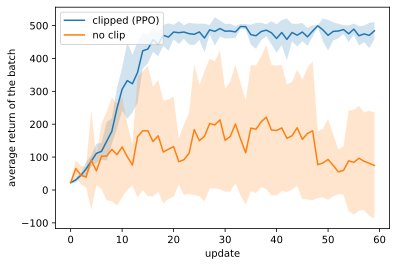

In [3]:

d2l.show_clip_ablation({
    'clipped (PPO)': lambda seed: train_ppo(seed, use_clip=True),
    'no clip': lambda seed: train_ppo(seed, use_clip=False)}, num_seeds)

In our run the unclipped control leaves most of the eight seeds dead at the end, several of them at a return of about 9, the score of a pole that falls immediately. That number is the two-action example made real: twenty unconstrained passes over one noisy batch add up to exactly the oversized policy change the sigmoid picture warned about, the policy lands in saturation, gradients vanish, and every later batch is collected by the broken policy, so no later data can undo it. The clipped runs take the same twenty passes over the same batches and every seed ends near the ceiling. Note also how rarely the insurance pays out: about two samples in a hundred ever get clipped. The clip does not need to fire often, because zeroing the gradient of exactly the samples whose ratios have left the band is what stops the runaway from compounding in the first place. When the unclipped variant survives it is fast, and at gentler settings, fewer epochs or a smaller learning rate, it survives almost always; the clip is insurance against the interaction of reuse with step size, not a speedup.

## Summary

Directly parameterized policies make step size treacherous: equal moves in parameter space can be a rewrite of the behavior or a no-op, so the quantity to control is the change in the policy, not the change in $\theta$. Importance sampling turns the objective of a new policy into an exact expectation over data from an old one; the trajectory-level weight is a product of policy ratios in which the transition probabilities cancel, unbiased but with variance that compounds along the horizon. The per-step surrogate the equation tames the variance at the price of being only a local model of the objective. TRPO bounds how far the policy may move with a KL constraint and buys a monotonic improvement guarantee; PPO gets most of the effect with a per-sample clip at $1 \pm \epsilon$, which zeroes a sample's gradient once its ratio leaves the band in the paying direction. On CartPole, twenty epochs of reuse per batch destroy most unclipped runs through the saturation collapse of the sigmoid example, while every clipped run trains to the ceiling with the clip touching only about two samples in a hundred. Advantage estimates plug in freely, from the Monte Carlo advantage used here to the TD error, with GAE interpolating between the two ends.

## Exercises

1. Implement GAE the equation: compute the $\delta_t$ sequence for each trajectory from the value network and form advantages with $\lambda \in \{0, 0.5, 0.95, 1\}$. Where do the two endpoints land relative to the methods you already know?
1. Sweep the clipping parameter $\epsilon$ over $\{0.05, 0.1, 0.2, 0.5, \infty\}$. When does small $\epsilon$ hurt, and how does $\epsilon = \infty$ relate to the no-clip control above?
1. Vary `num_epochs` over $\{1, 5, 10, 20, 40\}$ with and without clipping. At one epoch, why should the two variants behave nearly identically? Where does the unclipped variant start losing seeds?
1. Run the normalized REINFORCE of that section with a deliberately oversized learning rate, $\alpha = 50$, on a handful of seeds. Many runs never learn at all: the first noisy updates saturate the softmax, exactly as the two-action example predicts, and the score vanishes. Now add an entropy bonus $-c \sum_a \pi_\theta(a \mid s) \log \pi_\theta(a \mid s)$ to the per-sample objective. How large must $c$ be to prevent the collapse, and what does it cost when $\alpha = 2$?